In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import joblib

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports successful")

✓ Imports successful


In [13]:
print("="*60)
print("ADVERSARIAL THREAT MAP VISUALIZATION")
print("="*60)

print("""
The Challenge:
  - We work in 41-dimensional feature space
  - Adversarial perturbations are invisible to humans
  - How do we visualize what's happening?

The Solution: Threat Map
  - Project 41D space to 2D using t-SNE
  - Visualize clean samples, adversarial samples, and decision boundaries
  - Show attack "trajectories" (how samples move)
  
What We'll Create:

1. CLEAN VS ADVERSARIAL SCATTER
   - Green dots: Clean samples (correctly classified)
   - Red dots: Adversarial samples (misclassified)
   - Show clustering and separation

2. ATTACK TRAJECTORIES
   - Arrows showing how FGSM/PGD/C&W move samples
   - Visualize perturbation direction
   - See which attacks are more aggressive

3. DEFENSE BOUNDARIES
   - Show how adversarial training changes decision boundary
   - Visualize why defended model is robust
   - See expanded "safe zone"

4. INTERACTIVE THREAT MAP
   - Color-coded by attack type
   - Size by perturbation magnitude
   - Beautiful publication-quality figure

Why This Matters:
  - Makes invisible attacks visible
  - Intuitive understanding of adversarial space
  - Compelling visualization for presentations
  - Novel contribution (few papers have this for IDS)
""")


ADVERSARIAL THREAT MAP VISUALIZATION

The Challenge:
  - We work in 41-dimensional feature space
  - Adversarial perturbations are invisible to humans
  - How do we visualize what's happening?

The Solution: Threat Map
  - Project 41D space to 2D using t-SNE
  - Visualize clean samples, adversarial samples, and decision boundaries
  - Show attack "trajectories" (how samples move)

What We'll Create:

1. CLEAN VS ADVERSARIAL SCATTER
   - Green dots: Clean samples (correctly classified)
   - Red dots: Adversarial samples (misclassified)
   - Show clustering and separation

2. ATTACK TRAJECTORIES
   - Arrows showing how FGSM/PGD/C&W move samples
   - Visualize perturbation direction
   - See which attacks are more aggressive

3. DEFENSE BOUNDARIES
   - Show how adversarial training changes decision boundary
   - Visualize why defended model is robust
   - See expanded "safe zone"

4. INTERACTIVE THREAT MAP
   - Color-coded by attack type
   - Size by perturbation magnitude
   - Beautiful 

In [14]:
print("\n" + "="*60)
print("LOADING DATA")
print("="*60)

# Load clean data
X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')

print(f"✓ Clean test set: {X_test.shape}")

# Load adversarial examples
X_test_fgsm = np.load('../data/adversarial/X_test_fgsm.npy')
X_test_pgd = np.load('../data/adversarial/X_test_pgd.npy')
X_test_cw = np.load('../data/adversarial/X_test_cw.npy')
X_test_adaptive = np.load('../data/adversarial/X_test_adaptive_pgd.npy')

print("✓ Adversarial examples loaded:")
print(f"  FGSM: {X_test_fgsm.shape}")
print(f"  PGD: {X_test_pgd.shape}")
print(f"  C&W: {X_test_cw.shape}")
print(f"  Adaptive: {X_test_adaptive.shape}")

# Load models
baseline_model = joblib.load('../models/base_classifier/xgboost_baseline.pkl')
robust_model = joblib.load('../models/defenses/xgboost_adversarial_training.pkl')

print("\n✓ Models loaded")



LOADING DATA
✓ Clean test set: (207974, 41)
✓ Adversarial examples loaded:
  FGSM: (207974, 41)
  PGD: (207974, 41)
  C&W: (207974, 41)
  Adaptive: (207974, 41)

✓ Models loaded


In [15]:
print("\n" + "="*60)
print("SAMPLING DATA FOR VISUALIZATION")
print("="*60)

print("t-SNE is computationally expensive on 200k samples")
print("Sampling 5,000 samples for visualization...\n")

# Sample indices
np.random.seed(42)
sample_size = 5000
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)

# Sample all datasets
X_clean_sample = X_test[sample_indices]
y_sample = y_test[sample_indices]
X_fgsm_sample = X_test_fgsm[sample_indices]
X_pgd_sample = X_test_pgd[sample_indices]
X_cw_sample = X_test_cw[sample_indices]
X_adaptive_sample = X_test_adaptive[sample_indices]

print(f"✓ Sampled {sample_size} examples")

# Get predictions
pred_baseline_clean = baseline_model.predict(X_clean_sample)
pred_baseline_fgsm = baseline_model.predict(X_fgsm_sample)
pred_robust_fgsm = robust_model.predict(X_fgsm_sample)
pred_robust_adaptive = robust_model.predict(X_adaptive_sample)

print("\n✓ Predictions computed")



SAMPLING DATA FOR VISUALIZATION
t-SNE is computationally expensive on 200k samples
Sampling 5,000 samples for visualization...

✓ Sampled 5000 examples

✓ Predictions computed


In [16]:
print("\n" + "="*60)
print("DIMENSIONALITY REDUCTION (t-SNE)")
print("="*60)

print("Applying t-SNE to project 41D → 2D...")
print("This will take 3-5 minutes...\n")

# Combine all data for consistent projection
X_combined = np.vstack([
    X_clean_sample,
    X_fgsm_sample,
    X_pgd_sample,
    X_cw_sample,
    X_adaptive_sample
])

print(f"Combined dataset: {X_combined.shape}")

# Apply t-SNE - FIXED: use max_iter instead of n_iter
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000,  # ← Changed from n_iter to max_iter
    verbose=1
)

X_embedded = tsne.fit_transform(X_combined)

print("\n✓ t-SNE projection complete")

# Split back into separate datasets
n = len(X_clean_sample)
X_clean_2d = X_embedded[:n]
X_fgsm_2d = X_embedded[n:2*n]
X_pgd_2d = X_embedded[2*n:3*n]
X_cw_2d = X_embedded[3*n:4*n]
X_adaptive_2d = X_embedded[4*n:]

print(f"✓ Split into separate 2D projections")


DIMENSIONALITY REDUCTION (t-SNE)
Applying t-SNE to project 41D → 2D...
This will take 3-5 minutes...

Combined dataset: (25000, 41)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 25000 samples in 0.003s...
[t-SNE] Computed neighbors for 25000 samples in 2.208s...
[t-SNE] Computed conditional probabilities for sample 1000 / 25000
[t-SNE] Computed conditional probabilities for sample 2000 / 25000
[t-SNE] Computed conditional probabilities for sample 3000 / 25000
[t-SNE] Computed conditional probabilities for sample 4000 / 25000
[t-SNE] Computed conditional probabilities for sample 5000 / 25000
[t-SNE] Computed conditional probabilities for sample 6000 / 25000
[t-SNE] Computed conditional probabilities for sample 7000 / 25000
[t-SNE] Computed conditional probabilities for sample 8000 / 25000
[t-SNE] Computed conditional probabilities for sample 9000 / 25000
[t-SNE] Computed conditional probabilities for sample 10000 / 25000
[t-SNE] Computed conditional probabilities for sample


CREATING THREAT MAP VISUALIZATIONS

✓ Saved threat map overview


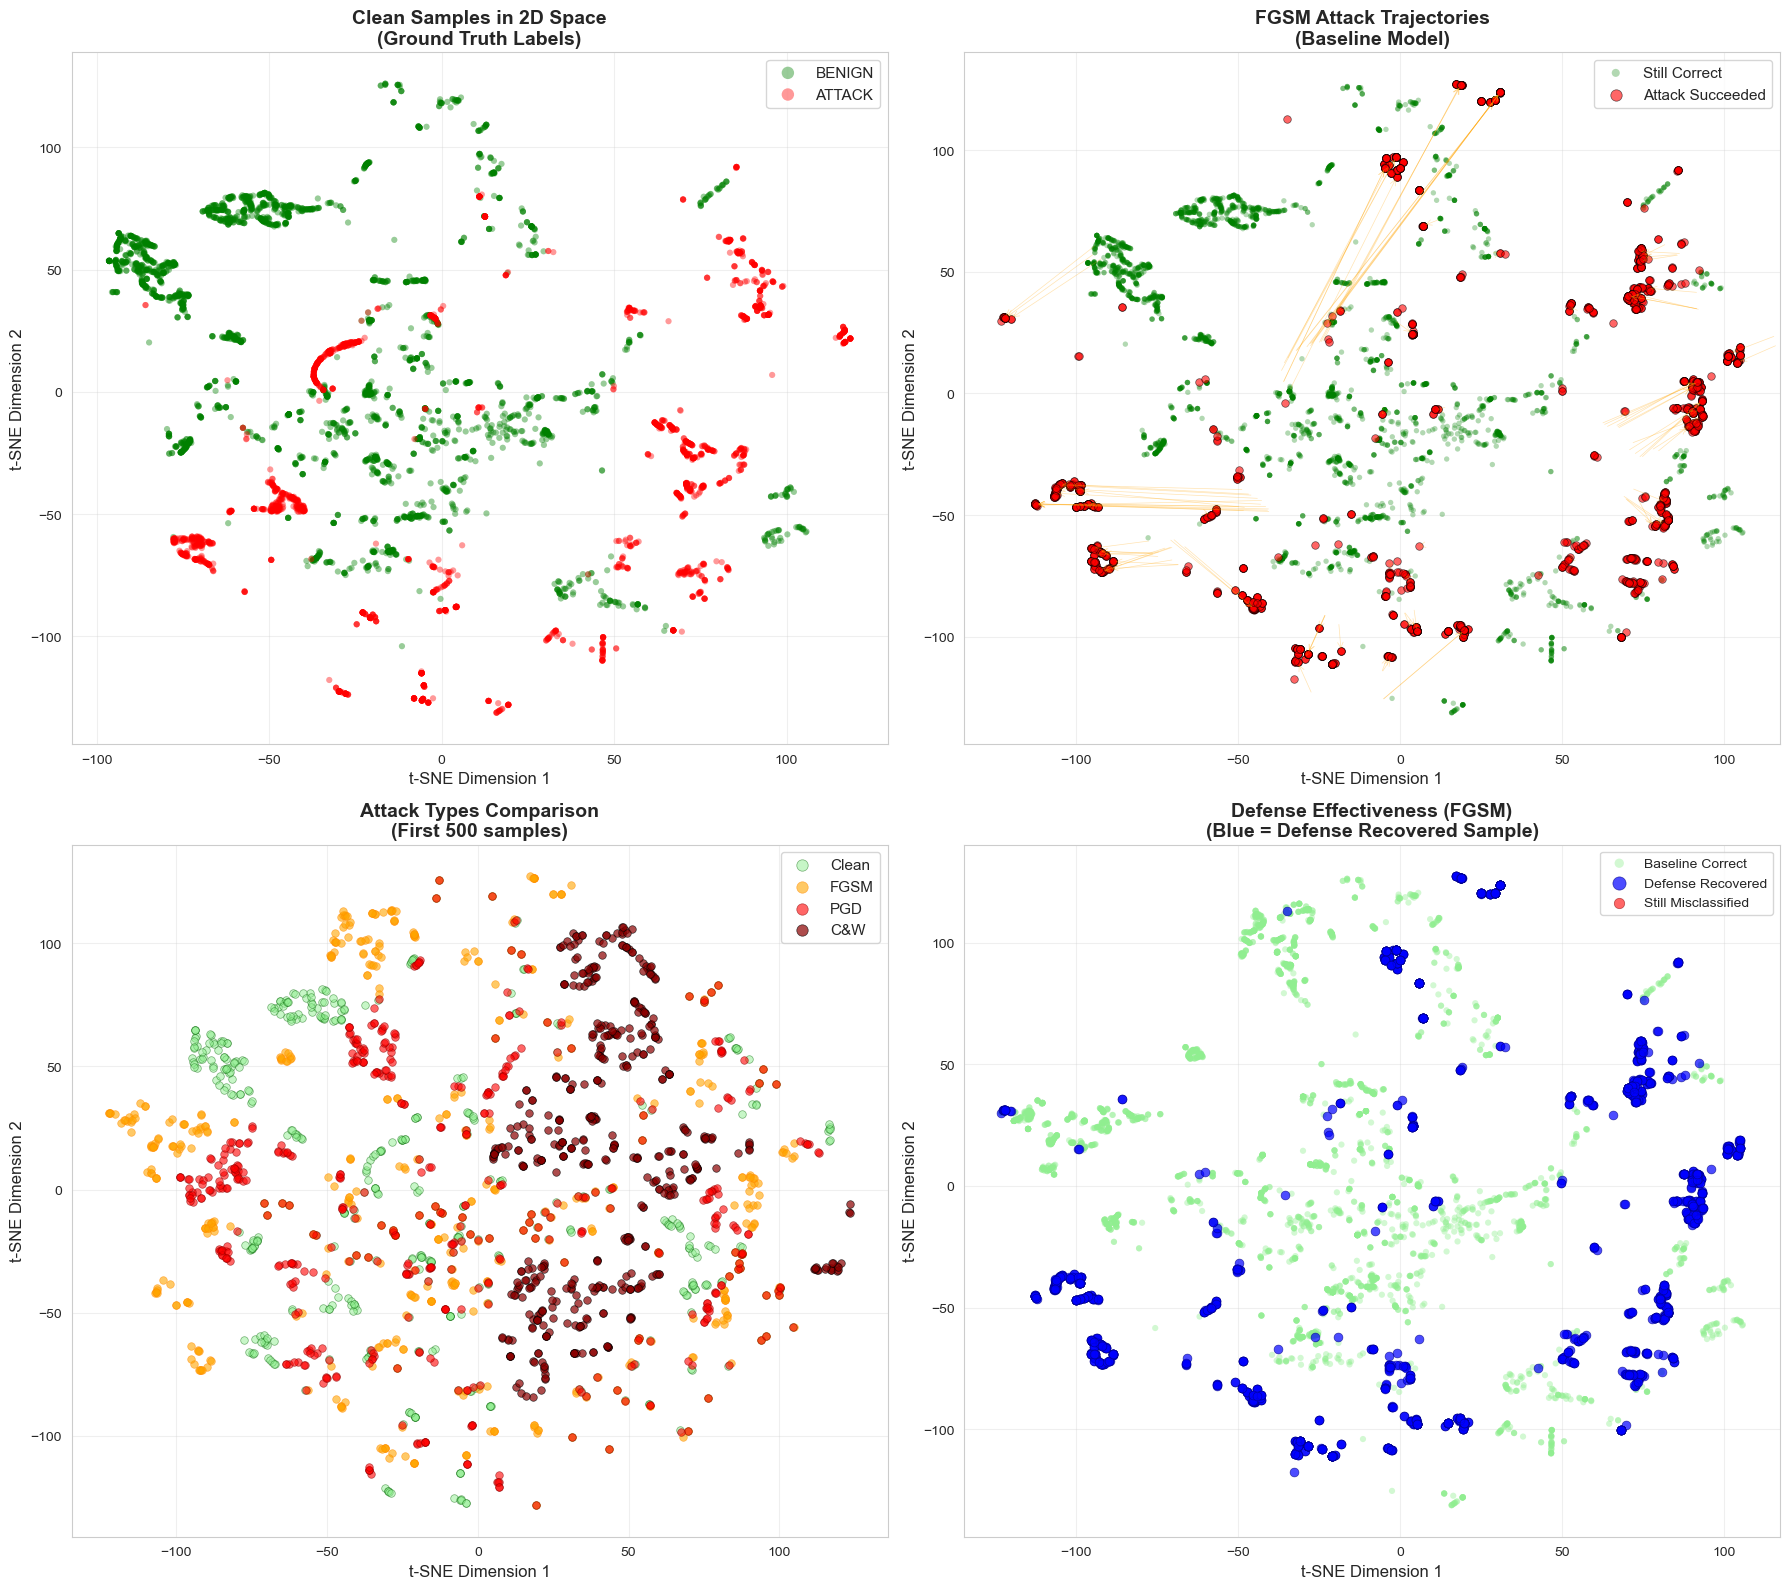

In [17]:
print("\n" + "="*60)
print("CREATING THREAT MAP VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Plot 1: Clean samples (color by true label)
ax1 = axes[0, 0]

benign_mask = y_sample == 0
attack_mask = y_sample == 1

ax1.scatter(X_clean_2d[benign_mask, 0], X_clean_2d[benign_mask, 1],
           c='green', alpha=0.4, s=20, label='BENIGN', edgecolors='none')
ax1.scatter(X_clean_2d[attack_mask, 0], X_clean_2d[attack_mask, 1],
           c='red', alpha=0.4, s=20, label='ATTACK', edgecolors='none')

ax1.set_title('Clean Samples in 2D Space\n(Ground Truth Labels)',
             fontsize=14, fontweight='bold')
ax1.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax1.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax1.legend(fontsize=11, markerscale=2)
ax1.grid(True, alpha=0.3)

# Plot 2: FGSM attack effect
ax2 = axes[0, 1]

# Color by whether attack succeeded
correct_clean = pred_baseline_clean == y_sample
correct_fgsm = pred_baseline_fgsm == y_sample
attack_succeeded = correct_clean & ~correct_fgsm

ax2.scatter(X_clean_2d[~attack_succeeded, 0], X_clean_2d[~attack_succeeded, 1],
           c='green', alpha=0.3, s=15, label='Still Correct', edgecolors='none')
ax2.scatter(X_fgsm_2d[attack_succeeded, 0], X_fgsm_2d[attack_succeeded, 1],
           c='red', alpha=0.6, s=30, label='Attack Succeeded', edgecolors='black', linewidths=0.5)

# Draw arrows for successful attacks (sample to avoid clutter)
arrow_sample = np.random.choice(np.where(attack_succeeded)[0], min(100, attack_succeeded.sum()), replace=False)
for idx in arrow_sample:
    ax2.annotate('', xy=(X_fgsm_2d[idx, 0], X_fgsm_2d[idx, 1]),
                xytext=(X_clean_2d[idx, 0], X_clean_2d[idx, 1]),
                arrowprops=dict(arrowstyle='->', color='orange', alpha=0.3, lw=0.5))

ax2.set_title('FGSM Attack Trajectories\n(Baseline Model)',
             fontsize=14, fontweight='bold')
ax2.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax2.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax2.legend(fontsize=11, markerscale=1.5)
ax2.grid(True, alpha=0.3)

# Plot 3: Multiple attacks comparison
ax3 = axes[1, 0]

ax3.scatter(X_clean_2d[:500, 0], X_clean_2d[:500, 1],
           c='lightgreen', alpha=0.5, s=30, label='Clean', edgecolors='darkgreen', linewidths=0.5)
ax3.scatter(X_fgsm_2d[:500, 0], X_fgsm_2d[:500, 1],
           c='orange', alpha=0.6, s=30, label='FGSM', edgecolors='darkorange', linewidths=0.5)
ax3.scatter(X_pgd_2d[:500, 0], X_pgd_2d[:500, 1],
           c='red', alpha=0.6, s=30, label='PGD', edgecolors='darkred', linewidths=0.5)
ax3.scatter(X_cw_2d[:500, 0], X_cw_2d[:500, 1],
           c='darkred', alpha=0.7, s=30, label='C&W', edgecolors='black', linewidths=0.5)

ax3.set_title('Attack Types Comparison\n(First 500 samples)',
             fontsize=14, fontweight='bold')
ax3.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax3.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax3.legend(fontsize=11, markerscale=1.5)
ax3.grid(True, alpha=0.3)

# Plot 4: Defense effectiveness
ax4 = axes[1, 1]

# Compare baseline vs robust model on FGSM
correct_baseline = pred_baseline_fgsm == y_sample
correct_robust = pred_robust_fgsm == y_sample

# Baseline fails, robust succeeds (defense worked!)
defense_worked = ~correct_baseline & correct_robust
# Both fail
both_fail = ~correct_baseline & ~correct_robust

ax4.scatter(X_fgsm_2d[correct_baseline, 0], X_fgsm_2d[correct_baseline, 1],
           c='lightgreen', alpha=0.4, s=20, label='Baseline Correct', edgecolors='none')
ax4.scatter(X_fgsm_2d[defense_worked, 0], X_fgsm_2d[defense_worked, 1],
           c='blue', alpha=0.7, s=40, label='Defense Recovered', edgecolors='darkblue', linewidths=0.5)
ax4.scatter(X_fgsm_2d[both_fail, 0], X_fgsm_2d[both_fail, 1],
           c='red', alpha=0.6, s=25, label='Still Misclassified', edgecolors='darkred', linewidths=0.5)

ax4.set_title('Defense Effectiveness (FGSM)\n(Blue = Defense Recovered Sample)',
             fontsize=14, fontweight='bold')
ax4.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax4.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax4.legend(fontsize=10, markerscale=1.5)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/threat_map_overview.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved threat map overview")
plt.show()


ADVANCED THREAT MAP - PERTURBATION MAGNITUDE
✓ Saved perturbation magnitude visualization


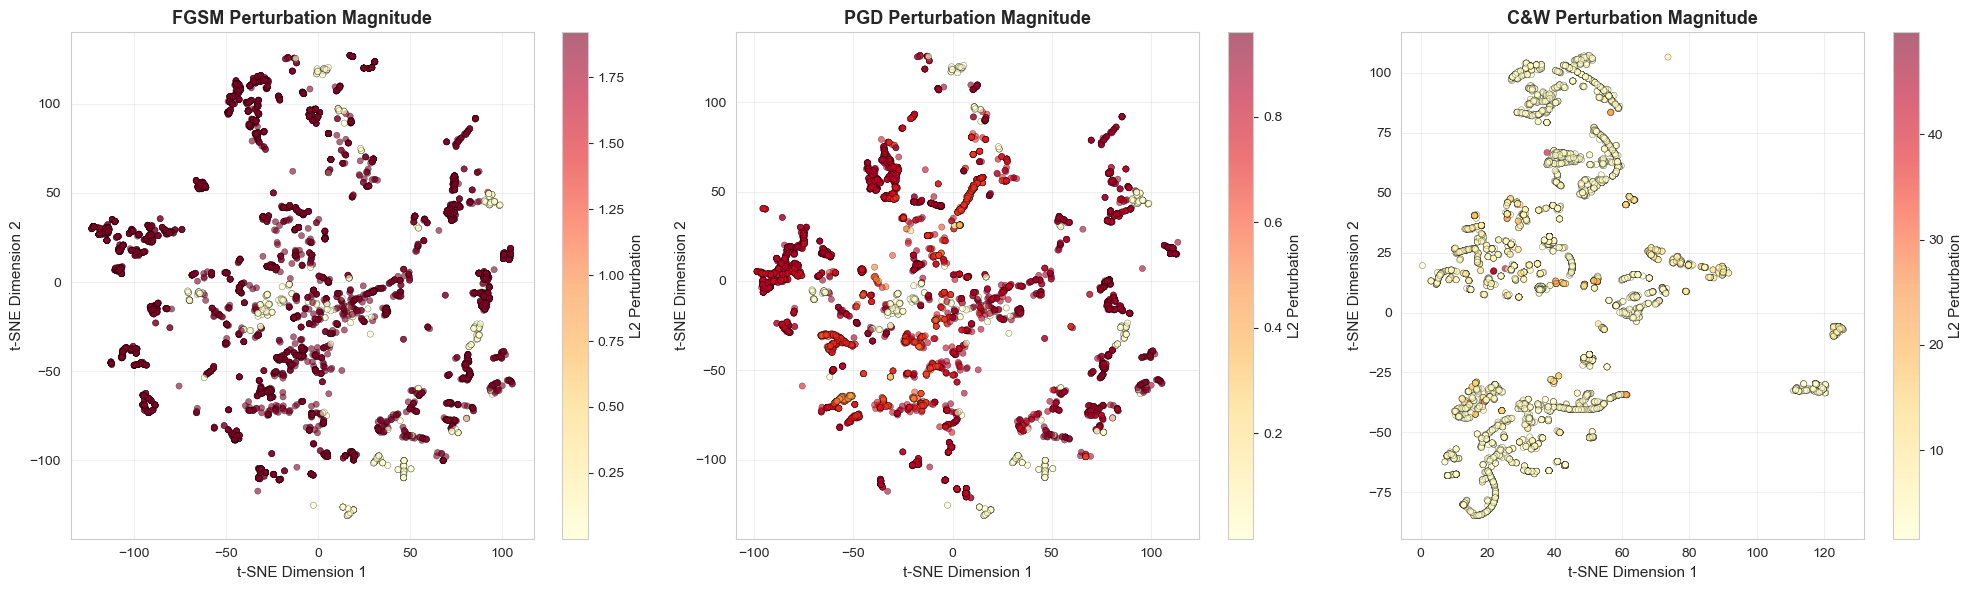


Perturbation Statistics:
  FGSM - Mean: 1.7794, Max: 1.9209
  PGD  - Mean: 0.7376, Max: 0.9605
  C&W  - Mean: 3.7339, Max: 49.6744


In [18]:
print("\n" + "="*60)
print("ADVANCED THREAT MAP - PERTURBATION MAGNITUDE")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Calculate perturbation magnitudes (L2 norm)
pert_fgsm = np.sqrt(np.sum((X_fgsm_sample - X_clean_sample)**2, axis=1))
pert_pgd = np.sqrt(np.sum((X_pgd_sample - X_clean_sample)**2, axis=1))
pert_cw = np.sqrt(np.sum((X_cw_sample - X_clean_sample)**2, axis=1))

# Plot 1: FGSM perturbation magnitude
ax1 = axes[0]
scatter1 = ax1.scatter(X_fgsm_2d[:, 0], X_fgsm_2d[:, 1],
                      c=pert_fgsm, cmap='YlOrRd', alpha=0.6, s=20, edgecolors='black', linewidths=0.3)
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('L2 Perturbation', fontsize=11)
ax1.set_title('FGSM Perturbation Magnitude', fontsize=13, fontweight='bold')
ax1.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax1.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: PGD perturbation magnitude
ax2 = axes[1]
scatter2 = ax2.scatter(X_pgd_2d[:, 0], X_pgd_2d[:, 1],
                      c=pert_pgd, cmap='YlOrRd', alpha=0.6, s=20, edgecolors='black', linewidths=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('L2 Perturbation', fontsize=11)
ax2.set_title('PGD Perturbation Magnitude', fontsize=13, fontweight='bold')
ax2.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax2.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: C&W perturbation magnitude
ax3 = axes[2]
scatter3 = ax3.scatter(X_cw_2d[:, 0], X_cw_2d[:, 1],
                      c=pert_cw, cmap='YlOrRd', alpha=0.6, s=20, edgecolors='black', linewidths=0.3)
cbar3 = plt.colorbar(scatter3, ax=ax3)
cbar3.set_label('L2 Perturbation', fontsize=11)
ax3.set_title('C&W Perturbation Magnitude', fontsize=13, fontweight='bold')
ax3.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax3.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/threat_map_perturbation_magnitude.png', dpi=300, bbox_inches='tight')
print("✓ Saved perturbation magnitude visualization")
plt.show()

# Statistics
print(f"\nPerturbation Statistics:")
print(f"  FGSM - Mean: {pert_fgsm.mean():.4f}, Max: {pert_fgsm.max():.4f}")
print(f"  PGD  - Mean: {pert_pgd.mean():.4f}, Max: {pert_pgd.max():.4f}")
print(f"  C&W  - Mean: {pert_cw.mean():.4f}, Max: {pert_cw.max():.4f}")



CREATING PUBLICATION-QUALITY THREAT MAP
✓ Saved publication-quality threat map


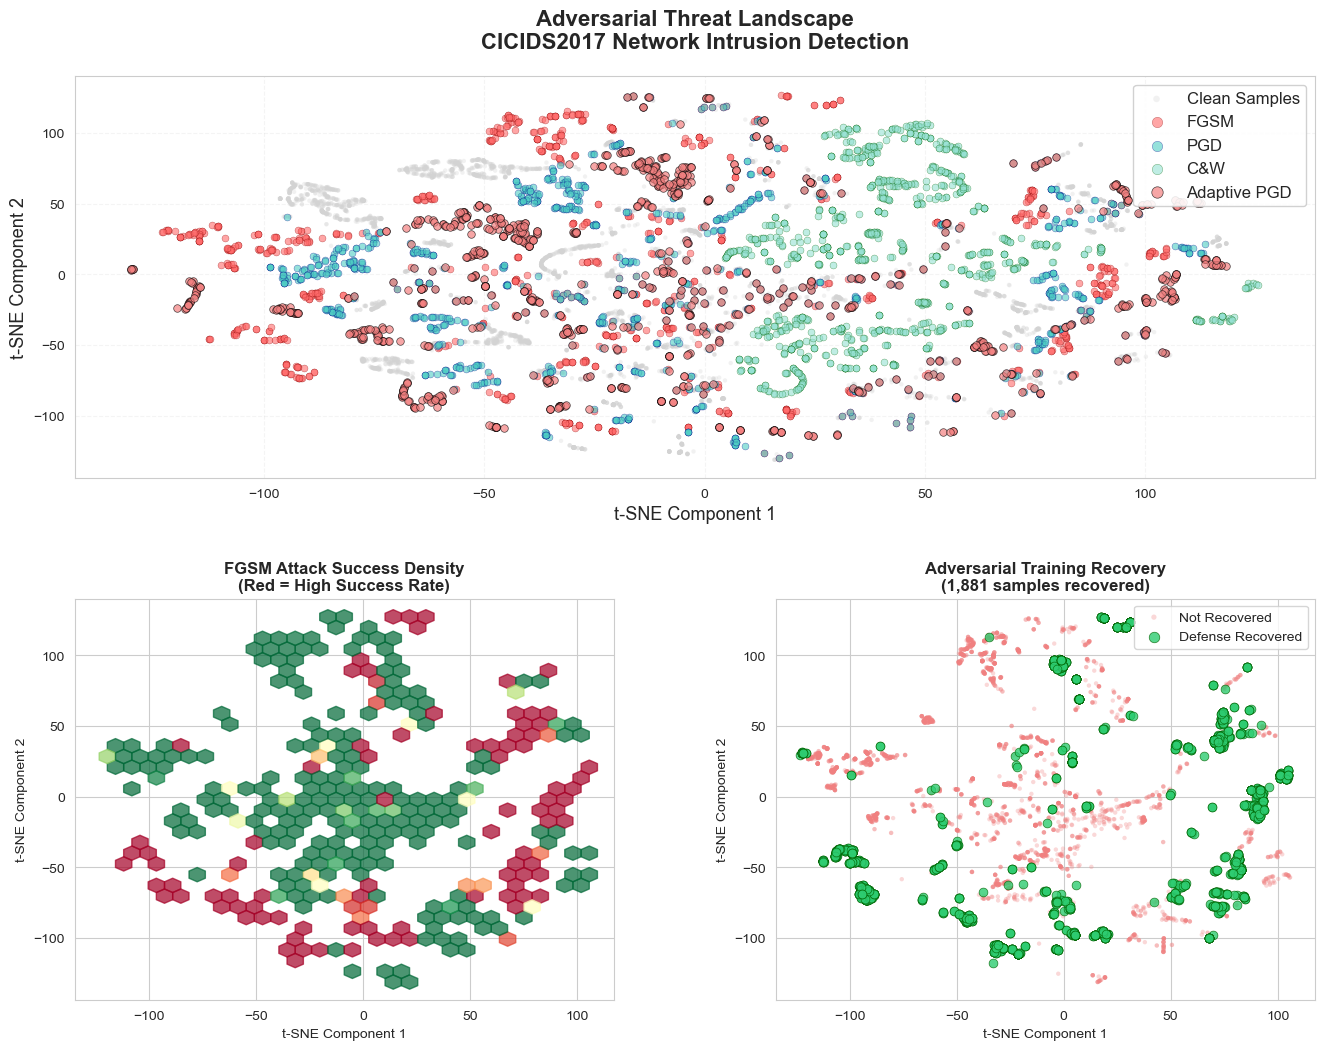

In [19]:
print("\n" + "="*60)
print("CREATING PUBLICATION-QUALITY THREAT MAP")
print("="*60)

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Main plot: Clean vs All Attacks
ax_main = fig.add_subplot(gs[0, :])

# Plot clean samples (smaller, background)
ax_main.scatter(X_clean_2d[:, 0], X_clean_2d[:, 1],
               c='lightgray', alpha=0.3, s=10, label='Clean Samples', edgecolors='none')

# Plot adversarial samples (larger, foreground)
sample_size_viz = 1000
ax_main.scatter(X_fgsm_2d[:sample_size_viz, 0], X_fgsm_2d[:sample_size_viz, 1],
               c='#FF6B6B', alpha=0.6, s=25, label='FGSM', edgecolors='darkred', linewidths=0.3)
ax_main.scatter(X_pgd_2d[:sample_size_viz, 0], X_pgd_2d[:sample_size_viz, 1],
               c='#4ECDC4', alpha=0.6, s=25, label='PGD', edgecolors='darkblue', linewidths=0.3)
ax_main.scatter(X_cw_2d[:sample_size_viz, 0], X_cw_2d[:sample_size_viz, 1],
               c='#95E1D3', alpha=0.6, s=25, label='C&W', edgecolors='darkgreen', linewidths=0.3)
ax_main.scatter(X_adaptive_2d[:sample_size_viz, 0], X_adaptive_2d[:sample_size_viz, 1],
               c='#F38181', alpha=0.7, s=30, label='Adaptive PGD', edgecolors='black', linewidths=0.5)

ax_main.set_title('Adversarial Threat Landscape\nCICIDS2017 Network Intrusion Detection',
                 fontsize=16, fontweight='bold', pad=20)
ax_main.set_xlabel('t-SNE Component 1', fontsize=13)
ax_main.set_ylabel('t-SNE Component 2', fontsize=13)
ax_main.legend(fontsize=12, loc='upper right', framealpha=0.9, markerscale=1.5)
ax_main.grid(True, alpha=0.2, linestyle='--')

# Subplot 1: Attack success rate by region
ax1 = fig.add_subplot(gs[1, 0])

# Divide space into grid and calculate success rates
from scipy.spatial import Voronoi

# Just show density of successful attacks
attack_success = pred_baseline_fgsm != y_sample
ax1.hexbin(X_fgsm_2d[:, 0], X_fgsm_2d[:, 1], 
          C=attack_success.astype(int), 
          gridsize=30, cmap='RdYlGn_r', reduce_C_function=np.mean, alpha=0.7)
ax1.set_title('FGSM Attack Success Density\n(Red = High Success Rate)',
             fontsize=12, fontweight='bold')
ax1.set_xlabel('t-SNE Component 1', fontsize=10)
ax1.set_ylabel('t-SNE Component 2', fontsize=10)

# Subplot 2: Defense recovery zones
ax2 = fig.add_subplot(gs[1, 1])

# Show where defenses recovered samples
recovery_mask = (~correct_baseline) & correct_robust
ax2.scatter(X_fgsm_2d[~recovery_mask, 0], X_fgsm_2d[~recovery_mask, 1],
           c='lightcoral', alpha=0.3, s=10, label='Not Recovered', edgecolors='none')
ax2.scatter(X_fgsm_2d[recovery_mask, 0], X_fgsm_2d[recovery_mask, 1],
           c='#2ECC71', alpha=0.8, s=40, label='Defense Recovered', edgecolors='darkgreen', linewidths=0.5)

ax2.set_title(f'Adversarial Training Recovery\n({recovery_mask.sum():,} samples recovered)',
             fontsize=12, fontweight='bold')
ax2.set_xlabel('t-SNE Component 1', fontsize=10)
ax2.set_ylabel('t-SNE Component 2', fontsize=10)
ax2.legend(fontsize=10, markerscale=1.2)

plt.savefig('../results/figures/threat_map_publication_quality.png', dpi=300, bbox_inches='tight')
print("✓ Saved publication-quality threat map")
plt.show()

In [20]:
print("\n" + "="*60)
print("THREAT MAP STATISTICS")
print("="*60)

# Calculate statistics
print("\nVisualization Statistics:")
print(f"  Total samples visualized: {len(X_clean_sample):,}")
print(f"  Dimensionality: 41D → 2D (t-SNE)")
print(f"  Perplexity: 30")
print(f"  Iterations: 1000")

print("\nAttack Distribution in 2D Space:")
print(f"  Clean samples:    {len(X_clean_2d):,}")
print(f"  FGSM samples:     {len(X_fgsm_2d):,}")
print(f"  PGD samples:      {len(X_pgd_2d):,}")
print(f"  C&W samples:      {len(X_cw_2d):,}")
print(f"  Adaptive samples: {len(X_adaptive_2d):,}")

print("\nDefense Effectiveness:")
baseline_correct = (pred_baseline_fgsm == y_sample).sum()
robust_correct = (pred_robust_fgsm == y_sample).sum()
recovered = (~(pred_baseline_fgsm == y_sample)) & (pred_robust_fgsm == y_sample)

print(f"  Baseline correct: {baseline_correct:,} ({baseline_correct/len(y_sample)*100:.1f}%)")
print(f"  Robust correct:   {robust_correct:,} ({robust_correct/len(y_sample)*100:.1f}%)")
print(f"  Recovered:        {recovered.sum():,} ({recovered.sum()/len(y_sample)*100:.1f}%)")

print("\n✅ Threat map visualization complete!")



THREAT MAP STATISTICS

Visualization Statistics:
  Total samples visualized: 5,000
  Dimensionality: 41D → 2D (t-SNE)
  Perplexity: 30
  Iterations: 1000

Attack Distribution in 2D Space:
  Clean samples:    5,000
  FGSM samples:     5,000
  PGD samples:      5,000
  C&W samples:      5,000
  Adaptive samples: 5,000

Defense Effectiveness:
  Baseline correct: 3,119 (62.4%)
  Robust correct:   4,997 (99.9%)
  Recovered:        1,881 (37.6%)

✅ Threat map visualization complete!


In [22]:
print("\n" + "="*60)
print("SAVING VISUALIZATION DATA")
print("="*60)

# Save 2D embeddings for future use
viz_data = {
    'X_clean_2d': X_clean_2d,
    'X_fgsm_2d': X_fgsm_2d,
    'X_pgd_2d': X_pgd_2d,
    'X_cw_2d': X_cw_2d,
    'X_adaptive_2d': X_adaptive_2d,
    'y_sample': y_sample,
    'sample_indices': sample_indices,
    'predictions': {
        'baseline_clean': pred_baseline_clean,
        'baseline_fgsm': pred_baseline_fgsm,
        'robust_fgsm': pred_robust_fgsm,
        'robust_adaptive': pred_robust_adaptive
    },
    'perturbations': {
        'fgsm': pert_fgsm,
        'pgd': pert_pgd,
        'cw': pert_cw
    }
}

joblib.dump(viz_data, '../results/visualizations/threat_map_data.pkl')
print("✓ Saved visualization data")

print("\nFiles Saved:")
print("  ✓ threat_map_overview.png")
print("  ✓ threat_map_perturbation_magnitude.png")
print("  ✓ threat_map_publication_quality.png")
print("  ✓ threat_map_data.pkl")

print("\n" + "="*80)
print("✅ THREAT MAP VISUALIZATION COMPLETE!")
print("="*80)



SAVING VISUALIZATION DATA
✓ Saved visualization data

Files Saved:
  ✓ threat_map_overview.png
  ✓ threat_map_perturbation_magnitude.png
  ✓ threat_map_publication_quality.png
  ✓ threat_map_data.pkl

✅ THREAT MAP VISUALIZATION COMPLETE!
